# deeptrack.pytorch.data

<a href="https://colab.research.google.com/github/DeepTrackAI/DeepTrack2/blob/develop/tutorials/3-advanced-topics/DTAT367_pytorch.data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# !pip install deeptrack  # Uncomment if running on Colab/Kaggle.

In [ ]:
# !pip install torch        # Uncomment if needed.
# !pip install torchvision  # Uncomment if needed.

This advanced tutorial introduces the module [deeptrack.pytorch.data](../../deeptrack/pytorch/data.py).
It follows closely the [DTGS111_datafiles](../1-getting-started/DTGS111_datafiles.ipynb) tutorial but focuses more on the functionality of the `Dataset` class.

## 1. What is `pytorch.data`?

The `pytorch.data` module provides a class named `Dataset`, which extends the PyTorch [Dataset](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html) class through direct inheritance. The DeepTrack2 `Dataset` class provides methods such as `.__getitem__()` and `.__len__()` that function similarily to `PyTorch Dataset`.

It can also take a data pipeline as an argument, letting you integrate transformations and augmentations as the data is being fetched/generated.

## 2. Downloading a Dataset


In [2]:
import os

import deeptrack as dt
import numpy as np
from torchvision.datasets.utils import download_url, _extract_zip

dataset_path = os.path.join(".", "blood_smears_dataset")
if not os.path.exists(dataset_path):
    url = "https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip"
    download_url(url, ".")
    _extract_zip("cell_images.zip", dataset_path, None)
    os.remove("cell_images.zip")

## 3. Using `Source` to Provide Metadata About the Data

In [3]:
files = dt.sources.ImageFolder(root=os.path.join(dataset_path, "cell_images"))
print(f"Dataset contains {len(files)} images")
print(f"There are {len(files)} files.")
print(f"The first file is {files[0]}.")

Dataset contains 27558 images
There are 27558 files.
The first file is SourceItem({'path': './blood_smears_dataset/cell_images/Parasitized/C100P61ThinF_IMG_20150918_144104_cell_162.png', 'label': 0, 'label_name': 'Parasitized'}, 1 callback(s)).


## 3. Combining Sources with Features

In [4]:
loader = dt.LoadImage(path=files.path)
label_pipeline = dt.Value(value=files.label)

loader_pipeline = loader >> dt.Resize((32, 32)) >> dt.Divide(255)

data_pipeline = loader_pipeline & label_pipeline

## 4. Creating a PyTorch Dataset
Finally, you implement the DeepTrack2 `Dataset` class by combining it with the data pipeline and the source of the files.

In [5]:
dataset = dt.pytorch.Dataset(data_pipeline, files)

## 5. Printing Information About the Dataset

Length of dataset: 27558
Item type: <class 'tuple'>
Shape of tensors: torch.Size([3, 32, 32])
tensor([1, 2, 3])


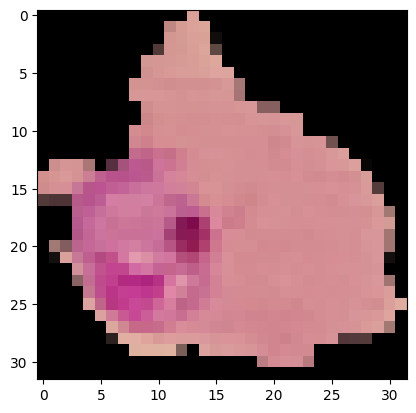

In [6]:
from matplotlib import pyplot as plt
import torch

print(f"Length of dataset: {dataset.__len__()}")
item = dataset.__getitem__(np.random.randint(100))

print(f"Item type: {type(item)}")

tensor = item[0]
print(f"Shape of tensors: {tensor.shape}")

# Permute to make it plottable.
tensor = torch.permute(tensor, (1, 2, 0))
plt.imshow(tensor)

# Additional utility to convert to a tensor.
numpy_array = np.array([1, 2, 3])
torch_tensor = dataset._as_tensor(numpy_array)

print(torch_tensor)

## 6. Generating Your Own Dataset

In [7]:
from IPython.display import HTML
from matplotlib.animation import FuncAnimation


# Function to play movie.
def play_movie(movie):
    fig, ax = plt.subplots(figsize=(6, 6))

    def update(frame):
        display_frame = movie[frame]
        ax.clear()
        plt.axis("off")
        plt.tight_layout(pad=0)
        ax.imshow(display_frame)

        return ax

    animation = FuncAnimation(fig, update, frames=len(movie))

    video = HTML(animation.to_jshtml())
    plt.close()
    return video

In [8]:
optics = dt.Fluorescence(
    NA=0.7,
    wavelength=680e-9,
    resolution=1e-6,
    magnification=10,
    output_region=(0, 0, 128, 128),
)

movie = []

# Starting rotation and position of particle.
phi = 0
pos = (64, 64)

for t in range(50):
    # Spinning motion
    phi += np.random.random() * np.pi / 5
    pos += np.random.standard_normal(2) * 5

    ellipse_0 = dt.Ellipse(
        intensity=100,
        position_unit="pixel",
        position=pos,
        radius=(1e-6, 0.1e-6),
        rotation=np.pi / 8 + phi,
    )
    ellipse_1 = dt.Ellipse(
        intensity=ellipse_0.intensity,
        position_unit="pixel",
        position=ellipse_0.position,
        radius=(1.5e-6, 0.1e-6),
        rotation=ellipse_0.rotation - np.pi / 3,
    )

    combined_scatterer = ellipse_0 >> ellipse_1
    imaged_scatterer = optics(combined_scatterer)
    movie.append(np.squeeze(imaged_scatterer.resolve()))

video = play_movie(movie)

## 7. Making It into a PyTorch Dataset

In [9]:
import random

# Randomly select a movie frame.
training_pipeline = random.choice(movie)

train_dataset = dt.pytorch.Dataset(training_pipeline, length=100)

print(train_dataset)